# Plant Disease Detection Pro
### EfficientNetB4 + Grad-CAM Explainability

| Feature | Detail |
|---|---|
| Architecture | EfficientNetB4 (240x240) |
| Datasets | PlantVillage + Ethiopian Coffee + Maize + Enset |
| Rejection | NOT_A_PLANT class |
| Explainability | Grad-CAM heatmaps |
| Training | 2-phase (head + fine-tune top 50 layers) |

## Cell 1 - Install and Setup

In [ ]:
!pip install kagglehub tensorflow-datasets opencv-python-headless -q

import os, shutil, random, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
from PIL import Image as PILImage
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print('TensorFlow :', tf.__version__)
print('Keras      :', keras.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))
print('Setup complete')

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup complete


## Cell 2 - Save Directory

In [ ]:
try:
    from google.colab import auth
    auth.authenticate_user()
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/plant_disease_pro'
    print('Using Google Drive')
except Exception as e:
    SAVE_DIR = '/content/plant_disease_pro'
    print('Drive not available - using local storage')
    print('Remember to download model at end!')

os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = f'{SAVE_DIR}/plant_disease_pro.keras'
print(f'Save path: {SAVE_PATH}')

Mounted at /content/drive
Using Google Drive
Save path: /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras


## Cell 3 - Kaggle API Setup

In [ ]:
import os, json

# Replace with your actual Kaggle credentials
KAGGLE_USERNAME = 'your_username_here'
KAGGLE_KEY      = 'your_key_here'

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
creds = {'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(creds, f)
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Kaggle API ready')

Kaggle API ready


## Cell 4 - Download All Datasets

In [ ]:
import kagglehub

print('Downloading datasets...')

print('1/4 PlantVillage...')
plant_path = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')
print(f'   Done: {plant_path}')

print('2/4 Ethiopian Coffee...')
coffee_path = kagglehub.dataset_download('biniyamyoseph/ethiopian-coffee-leaf-disease')
print(f'   Done: {coffee_path}')

print('3/4 Maize/Corn...')
maize_path = kagglehub.dataset_download('smaranjitghose/corn-or-maize-leaf-disease-dataset')
print(f'   Done: {maize_path}')

print('4/4 Enset...')
try:
    enset_path = kagglehub.dataset_download('beteaberra/enset1')
    print(f'   Done: {enset_path}')
except:
    enset_path = None
    print('   Enset not available - skipping')

print('All downloads complete')

1/4 PlantVillage...
Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
   Done: /kaggle/input/new-plant-diseases-dataset
2/4 Ethiopian Coffee...


100%|██████████| 1.91G/1.91G [01:45<00:00, 19.5MB/s]

Extracting files...


   Done: /root/.cache/kagglehub/datasets/biniyamyoseph/ethiopian-coffee-leaf-disease/versions/1
3/4 Maize/Corn...
Using Colab cache for faster access to the 'corn-or-maize-leaf-disease-dataset' dataset.
   Done: /kaggle/input/corn-or-maize-leaf-disease-dataset
4/4 Enset...


100%|██████████| 38.0M/38.0M [00:03<00:00, 10.3MB/s]

Extracting files...


   Done: /root/.cache/kagglehub/datasets/beteaberra/enset1/versions/1
All downloads complete


## Cell 5 - Build Non-Plant Rejection Dataset

In [ ]:
import tensorflow_datasets as tfds

NON_PLANT_DIR = '/content/non_plant_images'
os.makedirs(NON_PLANT_DIR, exist_ok=True)

print('Building NOT_A_PLANT rejection class...')

count = 0
TARGET = 2000

try:
    ds = tfds.load('cats_vs_dogs', split='train[:10%]', as_supervised=True)
    for img, _ in ds:
        if count >= TARGET:
            break
        try:
            pil_img = PILImage.fromarray(img.numpy().astype('uint8'))
            pil_img.save(f'{NON_PLANT_DIR}/animal_{count:05d}.jpg')
            count += 1
        except:
            continue
    print(f'Downloaded {count} animal images')
except Exception as e:
    print(f'cats_vs_dogs failed: {e}')

# Add synthetic noise images
print('Adding synthetic non-plant images...')
for i in range(500):
    arr = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
    PILImage.fromarray(arr).save(f'{NON_PLANT_DIR}/noise_{i:04d}.jpg')

total = len(os.listdir(NON_PLANT_DIR))
print(f'Total non-plant images: {total}')

Building NOT_A_PLANT rejection class...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.HBRPOI_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Downloaded 2000 animal images
Adding synthetic non-plant images...
Total non-plant images: 2500


## Cell 6 - Merge All Datasets

In [ ]:
MERGED_DIR = '/content/merged_dataset'
IMG_EXTS   = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG'}
TRAIN_R, VAL_R = 0.70, 0.15

def collect_classes(base_path, prefix=''):
    base = Path(base_path)
    class_dirs = {}
    for path in base.rglob('*'):
        if path.is_dir():
            imgs = [f for f in path.iterdir()
                    if f.is_file() and f.suffix in IMG_EXTS]
            if len(imgs) >= 10:
                name = f'{prefix}{path.name}' if prefix else path.name
                if name not in class_dirs:
                    class_dirs[name] = (path, imgs)
    return class_dirs

def split_and_copy(class_dirs, merged_dir):
    counts = {'train': 0, 'val': 0, 'test': 0}
    for cls in class_dirs:
        for split in ['train', 'val', 'test']:
            os.makedirs(f'{merged_dir}/{split}/{cls}', exist_ok=True)
    for cls, (src_dir, imgs) in class_dirs.items():
        random.shuffle(imgs)
        n       = len(imgs)
        n_train = int(n * TRAIN_R)
        n_val   = int(n * VAL_R)
        splits  = {
            'train': imgs[:n_train],
            'val'  : imgs[n_train:n_train+n_val],
            'test' : imgs[n_train+n_val:]
        }
        for split, files in splits.items():
            for f in files:
                dst = f'{merged_dir}/{split}/{cls}/{f.name}'
                if not os.path.exists(dst):
                    shutil.copy2(f, dst)
                counts[split] += 1
    return counts

all_classes = {}

print('Collecting PlantVillage...')
pv = collect_classes(plant_path)
all_classes.update(pv)
print(f'  {len(pv)} classes')

print('Collecting Ethiopian Coffee...')
cf = collect_classes(coffee_path, prefix='Coffee___')
all_classes.update(cf)
print(f'  {len(cf)} classes')

print('Collecting Maize...')
mz = collect_classes(maize_path, prefix='Maize___')
mz = {k: v for k, v in mz.items() if k not in all_classes}
all_classes.update(mz)
print(f'  {len(mz)} new classes')

if enset_path:
    print('Collecting Enset...')
    en = collect_classes(enset_path, prefix='Enset___')
    all_classes.update(en)
    print(f'  {len(en)} classes')

print('Adding NOT_A_PLANT rejection class...')
nonplant_imgs = [Path(NON_PLANT_DIR) / f
                 for f in os.listdir(NON_PLANT_DIR)
                 if f.endswith(('.jpg', '.jpeg', '.png'))]
all_classes['NOT_A_PLANT'] = (Path(NON_PLANT_DIR), nonplant_imgs)
print(f'  {len(nonplant_imgs)} non-plant images')

print(f'Total classes: {len(all_classes)}')
print('Merging and splitting...')
counts = split_and_copy(all_classes, MERGED_DIR)

print('Dataset merged')
for split, n in counts.items():
    print(f'  {split}: {n:,} images')

CLASS_NAMES = sorted(all_classes.keys())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Final classes: {NUM_CLASSES}')

  39 classes
  4 classes
  4 new classes
  2 classes
Adding NOT_A_PLANT rejection class...
  2500 non-plant images
Total classes: 50
Merging and splitting...
Dataset merged
  train: 25,242 images
  val: 5,392 images
  test: 5,458 images
Final classes: 50


## Cell 7 - Data Pipeline with Strong Augmentation

In [ ]:
IMG_SIZE   = 240
BATCH_SIZE = 8
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = keras.utils.image_dataset_from_directory(
    f'{MERGED_DIR}/train',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=SEED
)
val_ds = keras.utils.image_dataset_from_directory(
    f'{MERGED_DIR}/val',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)
test_ds = keras.utils.image_dataset_from_directory(
    f'{MERGED_DIR}/test',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
NOT_A_PLANT_IDX = CLASS_NAMES.index('NOT_A_PLANT') if 'NOT_A_PLANT' in CLASS_NAMES else -1
print(f'Classes        : {NUM_CLASSES}')
print(f'NOT_A_PLANT idx: {NOT_A_PLANT_IDX}')

# Strong augmentation simulating real-world conditions
augment = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.3),
    layers.RandomZoom((-0.3, 0.3)),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.3),
    layers.GaussianNoise(0.05),
], name='strong_augmentation')

def preprocess_efficientnet(images, labels):
    images = tf.cast(images, tf.float32)
    images = tf.keras.applications.efficientnet.preprocess_input(images)
    return images, labels

def augment_and_preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = augment(images, training=True)
    images = tf.keras.applications.efficientnet.preprocess_input(images)
    return images, labels

train_ds = train_ds.map(augment_and_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_efficientnet,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_efficientnet, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Data pipeline ready')
print(f'Train batches: {len(train_ds)}')
print(f'Val batches  : {len(val_ds)}')
print(f'Test batches : {len(test_ds)}')

Found 25242 files belonging to 50 classes.
Found 5392 files belonging to 50 classes.
Found 5458 files belonging to 50 classes.
Classes        : 50
NOT_A_PLANT idx: 25
Data pipeline ready
Train batches: 3156
Val batches  : 674
Test batches : 683


## Cell 8 - Build EfficientNetB4 Model

In [ ]:
def build_model(num_classes, img_size=240, dropout=0.4):
    inputs = keras.Input(shape=(img_size, img_size, 3), name='input_image')

    base = keras.applications.EfficientNetB4(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    base.trainable = False

    # --- Grad-CAM target layer ---
    # We use the last conv layer of EfficientNetB4
    # This is where Grad-CAM will extract its heatmap from
    gradcam_layer = 'top_activation'  # last activation in EfficientNetB4

    x = base.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(dropout, name='drop1')(x)
    x = layers.Dense(
        1024, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense1'
    )(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(dropout / 2, name='drop2')(x)
    x = layers.Dense(
        512, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense2'
    )(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Dropout(dropout / 4, name='drop3')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='PlantDiseaseProV1')
    return model, base, gradcam_layer


model, base_model, GRADCAM_LAYER = build_model(NUM_CLASSES)

total     = model.count_params()
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Model           : EfficientNetB4')
print(f'Input size      : {IMG_SIZE}x{IMG_SIZE}')
print(f'Classes         : {NUM_CLASSES}')
print(f'Grad-CAM layer  : {GRADCAM_LAYER}')
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,} (head only)')

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Model           : EfficientNetB4
Input size      : 240x240
Classes         : 50
Grad-CAM layer  : top_activation
Total params    : 20,073,617
Trainable params: 2,393,138 (head only)


## Cell 9 - Compute Class Weights

Class weights computed
Min weight: 0.267
Max weight: 21.950


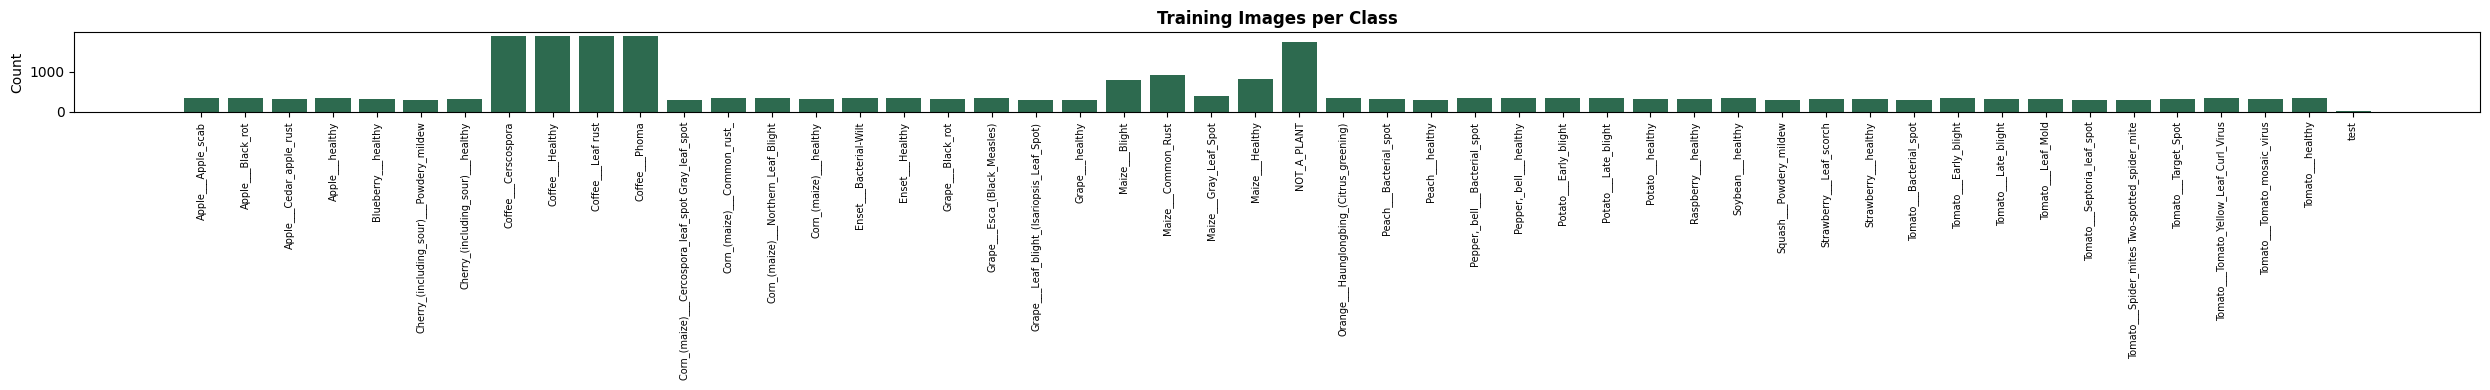

Class distribution saved


In [ ]:
class_counts = {}
for cls in CLASS_NAMES:
    path = Path(f'{MERGED_DIR}/train/{cls}')
    class_counts[cls] = len(list(path.iterdir())) if path.exists() else 0

counts_arr = np.array([class_counts[c] for c in CLASS_NAMES])
total_imgs = counts_arr.sum()
class_weights = {}
for i, cls in enumerate(CLASS_NAMES):
    if counts_arr[i] > 0:
        class_weights[i] = float(total_imgs / (NUM_CLASSES * counts_arr[i]))
    else:
        class_weights[i] = 1.0

print('Class weights computed')
print(f'Min weight: {min(class_weights.values()):.3f}')
print(f'Max weight: {max(class_weights.values()):.3f}')

fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES // 2), 4))
ax.bar(range(NUM_CLASSES), counts_arr, color='#2d6a4f')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
ax.set_title('Training Images per Class', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=100)
plt.show()
print('Class distribution saved')

## Cell 10 - Phase 1: Train Classification Head

In [ ]:
callbacks_p1 = [
    keras.callbacks.ModelCheckpoint(
        SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.CSVLogger(f'{SAVE_DIR}/phase1_log.csv')
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy',
             keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy')]
)

print('=' * 60)
print('PHASE 1 - Training classification head (base frozen)')
print('=' * 60)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_p1,
    class_weight=class_weights
)

best_val = max(history1.history['val_accuracy'])
print(f'Phase 1 complete. Best val accuracy: {best_val:.2%}')

PHASE 1 - Training classification head (base frozen)
Epoch 1/15
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4248 - loss: 3.0677 - top3_accuracy: 0.6724
Epoch 1: val_accuracy improved from None to 0.65152, saving model to /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 771s 224ms/step - accuracy: 0.5027 - loss: 2.7894 - top3_accuracy: 0.7608 - val_accuracy: 0.6515 - val_loss: 2.2757 - val_top3_accuracy: 0.8958 - learning_rate: 0.0010
Epoch 2/15
3155/3156 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.5769 - loss: 2.6114 - top3_accuracy: 0.8436
Epoch 2: val_accuracy improved from 0.65152 to 0.71736, saving model to /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 625s 198ms/step - 

## Cell 11 - Phase 2: Fine-tune Top 50 Layers

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Trainable params after unfreeze: {trainable:,}')

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint(
        SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    keras.callbacks.CSVLogger(f'{SAVE_DIR}/phase2_log.csv')
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy',
             keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy')]
)

print('=' * 60)
print('PHASE 2 - Fine-tuning top 50 EfficientNetB4 layers')
print('=' * 60)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_p2,
    class_weight=class_weights
)

best_val2 = max(history2.history['val_accuracy'])
print(f'Phase 2 complete. Best val accuracy: {best_val2:.2%}')

Trainable params after unfreeze: 9,243,050
PHASE 2 - Fine-tuning top 50 EfficientNetB4 layers
Epoch 1/15
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7488 - loss: 1.6361 - top3_accuracy: 0.9503
Epoch 1: val_accuracy improved from None to 0.85942, saving model to /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 735s 213ms/step - accuracy: 0.7706 - loss: 1.5735 - top3_accuracy: 0.9598 - val_accuracy: 0.8594 - val_loss: 1.2933 - val_top3_accuracy: 0.9889 - learning_rate: 5.0000e-05
Epoch 2/15
3155/3156 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7927 - loss: 1.4602 - top3_accuracy: 0.9690
Epoch 2: val_accuracy improved from 0.85942 to 0.86499, saving model to /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras
3156

KeyboardInterrupt: 

## Cell 12 - Training Curves

In [ ]:
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']
top3 = history1.history['top3_accuracy']
val_top3 = history1.history['val_top3_accuracy']

# Add history2 only if it exists
if 'history2' in globals():
    acc      += history2.history['accuracy']
    val_acc  += history2.history['val_accuracy']
    loss     += history2.history['loss']
    val_loss += history2.history['val_loss']
    top3     += history2.history['top3_accuracy']
    val_top3 += history2.history['val_top3_accuracy']

p1_end = len(history1.history['accuracy'])

## Cell 13 - Test Evaluation

In [ ]:
best_model = keras.models.load_model(SAVE_PATH)
test_loss, test_acc, test_top3 = best_model.evaluate(test_ds, verbose=1)

print(f'\n{"="*50}')
print(f'Test Accuracy  : {test_acc:.2%}')
print(f'Top-3 Accuracy : {test_top3:.2%}')
print(f'Test Loss      : {test_loss:.4f}')
print(f'{"="*50}')

y_pred, y_true = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print('Per-Class Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

683/683 ━━━━━━━━━━━━━━━━━━━━ 55s 56ms/step - accuracy: 0.8642 - loss: 1.1847 - top3_accuracy: 0.9921

Test Accuracy  : 86.42%
Top-3 Accuracy : 99.21%
Test Loss      : 1.1847
Per-Class Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.986     0.909     0.946        77
                                 Apple___Black_rot      0.914     0.974     0.943        76
                          Apple___Cedar_apple_rust      0.984     0.924     0.953        66
                                   Apple___healthy      0.927     1.000     0.962        76
                               Blueberry___healthy      1.000     0.986     0.993        69
          Cherry_(including_sour)___Powdery_mildew      0.984     0.969     0.976        64
                 Cherry_(including_sour)___healthy      0.958     1.000     0.979        69
                              Coffee___Cerscospora      0.984     0.901

## Cell 14 - Confusion Matrix

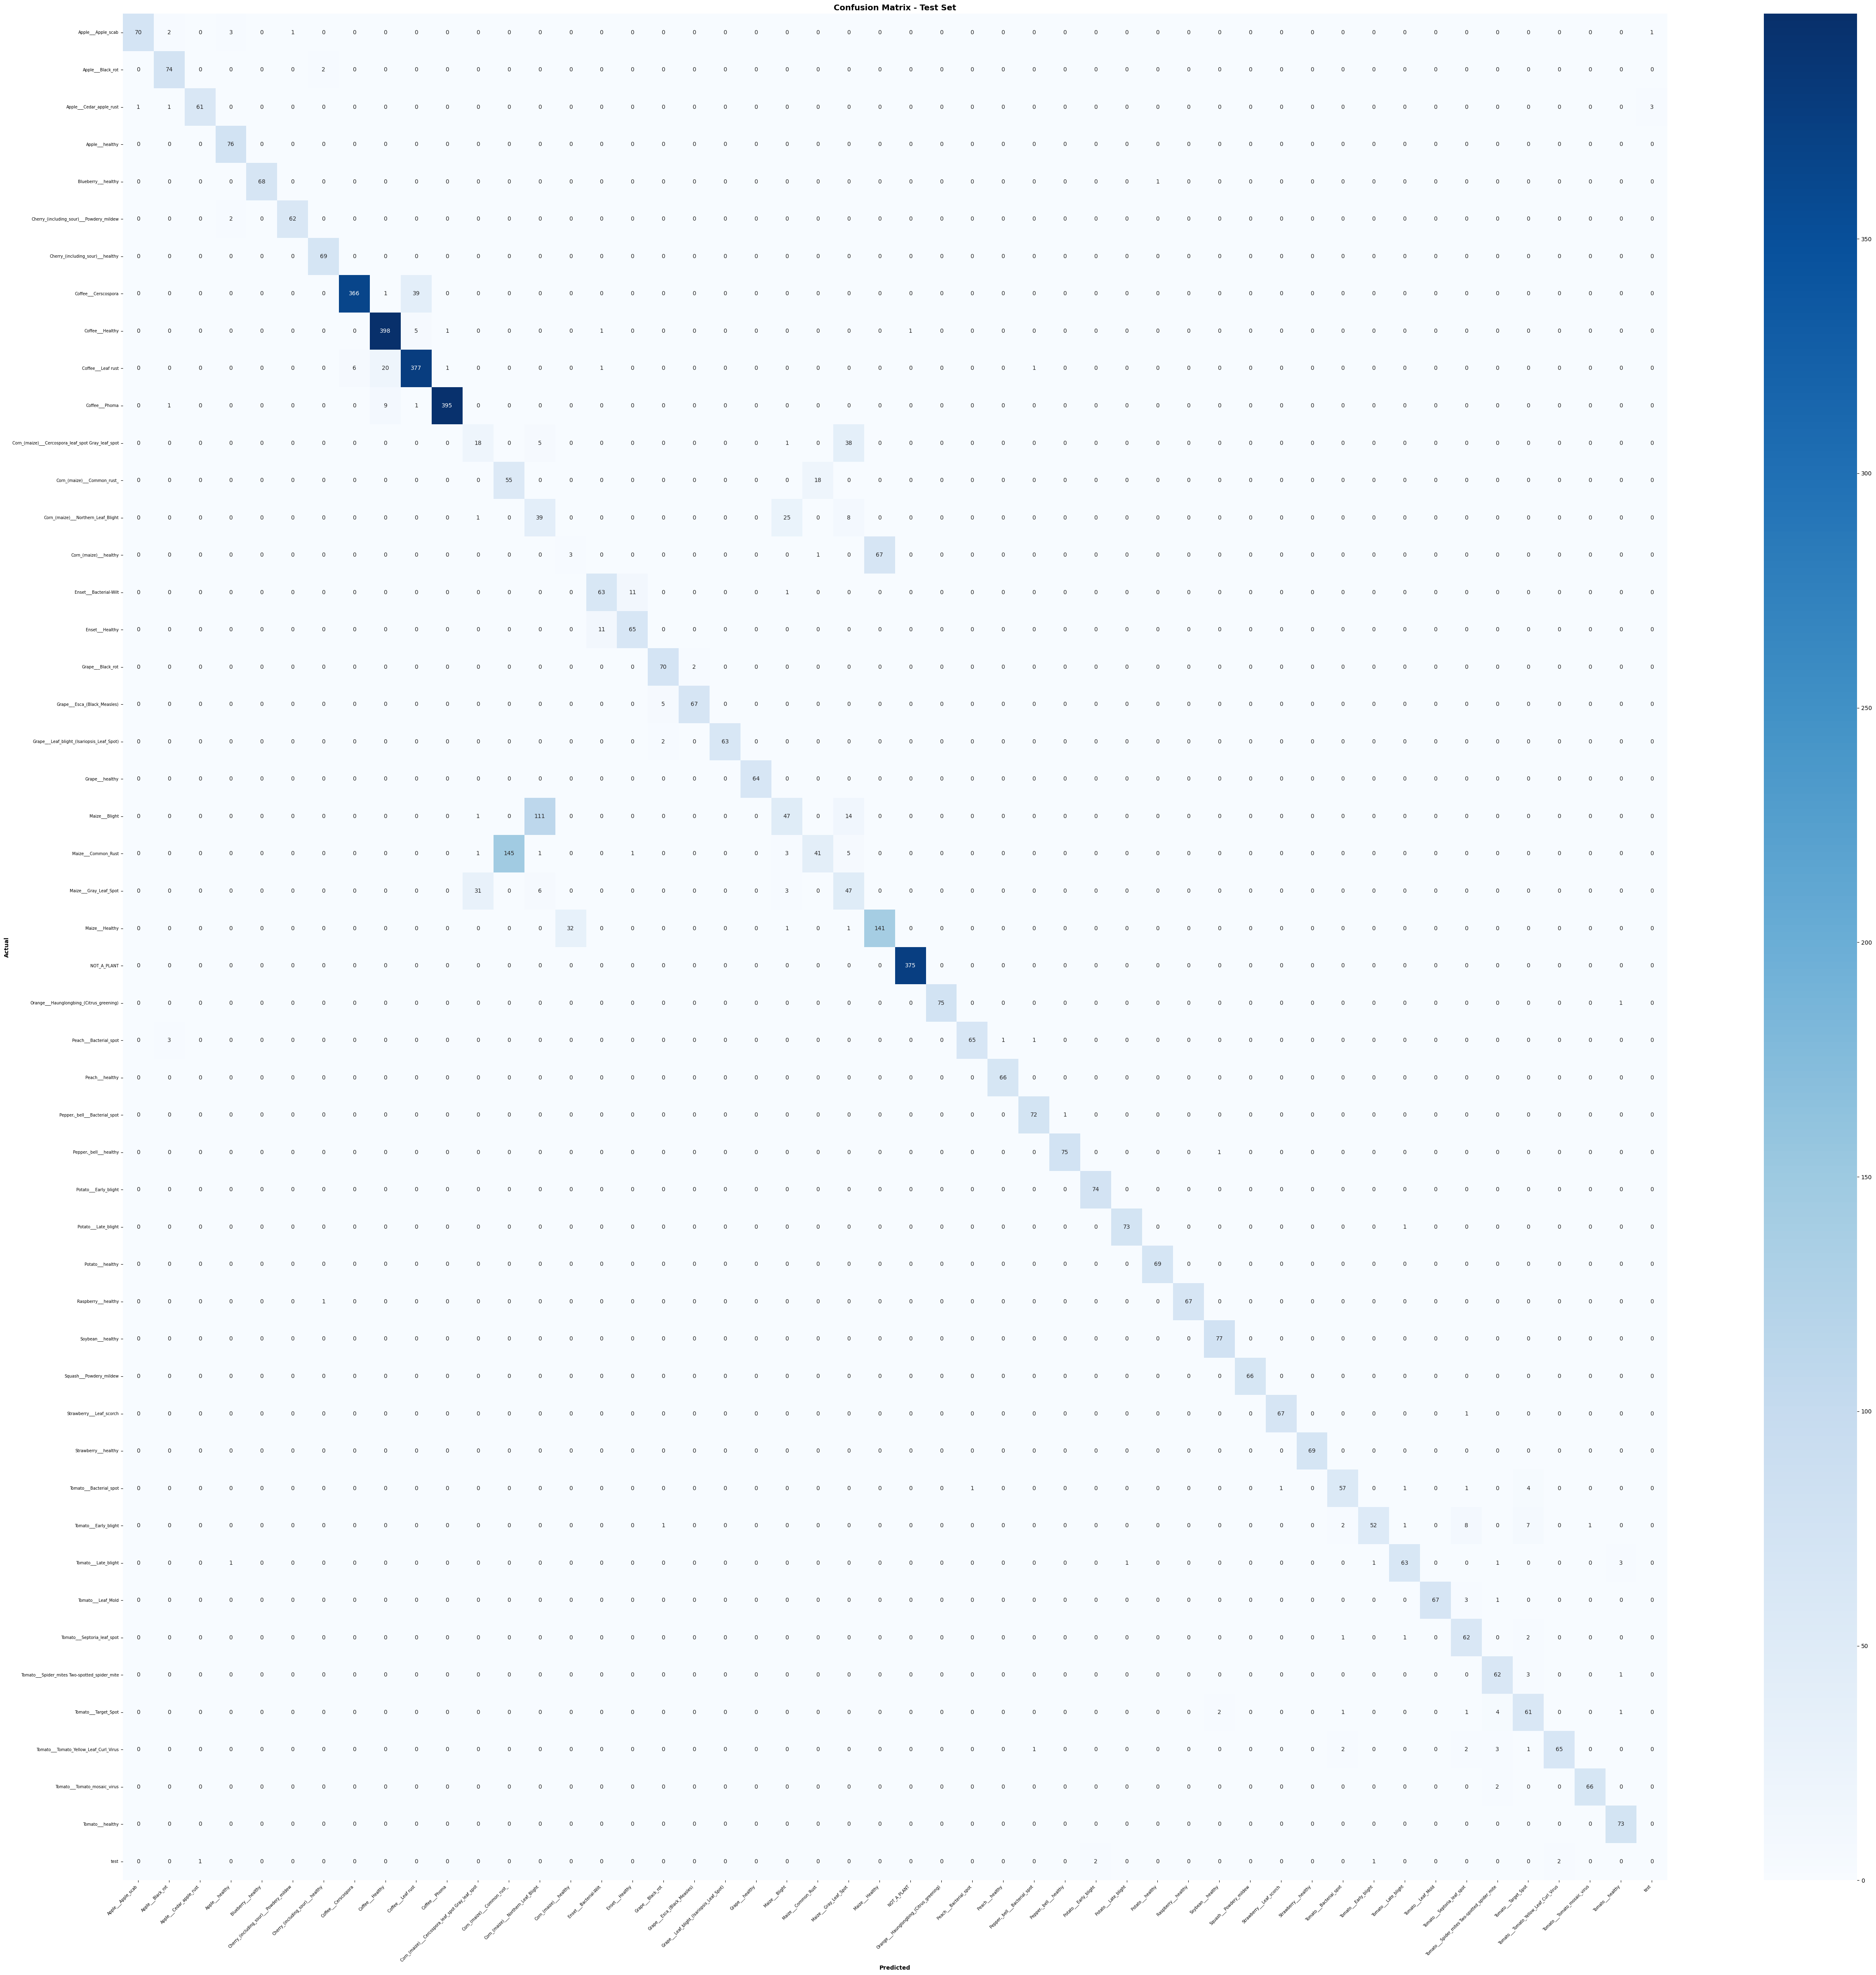

Confusion matrix saved


In [ ]:
cm_matrix = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES), max(12, NUM_CLASSES - 2)))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual',    fontweight='bold')
ax.set_title('Confusion Matrix - Test Set', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved')

## Cell 15 - Grad-CAM Implementation

Grad-CAM shows WHICH part of the leaf the model focused on to make its prediction.
- Red/Yellow areas = where the model detected disease
- Blue areas = where the model ignored

This makes your system EXPLAINABLE and TRUSTWORTHY.

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for a given image.

    How it works:
    1. Pass image through model up to the last conv layer
    2. Compute gradients of predicted class w.r.t. conv layer output
    3. Pool gradients spatially (global average)
    4. Weight conv output channels by their gradients
    5. Average across channels => heatmap
    6. Apply ReLU (keep only positive activations)
    """
    # Create a model that outputs both the conv layer and final predictions
    grad_model = keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(inputs)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradient of predicted class w.r.t. conv layer output
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight conv outputs by pooled gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_array, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlay Grad-CAM heatmap onto original image.
    Returns the overlaid image as numpy array.
    """
    # Resize heatmap to match image size
    img = img_array[0].copy()

    # Denormalize from EfficientNet preprocessing
    img = (img + 1) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)

    # Resize heatmap
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert to colormap
    heatmap_uint8  = np.uint8(255 * heatmap_resized)
    heatmap_color  = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_color  = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Overlay
    overlaid = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    return img, heatmap_color, overlaid


def predict_with_gradcam(image_source, model, class_names,
                          gradcam_layer='top_activation',
                          top_k=5,
                          rejection_threshold=0.60,
                          save_path=None):
    """
    Full prediction pipeline with Grad-CAM visualization.

    Args:
        image_source : file path or URL string
        model        : trained keras model
        class_names  : list of class names
        gradcam_layer: name of last conv layer for Grad-CAM
        top_k        : number of top predictions to show
        rejection_threshold: min confidence to accept prediction
        save_path    : optional path to save the figure

    Returns:
        dict with prediction results and heatmap
    """

    # Load image
    if str(image_source).startswith('http'):
        import urllib.request, tempfile
        tmp = tempfile.NamedTemporaryFile(suffix='.jpg', delete=False)
        urllib.request.urlretrieve(str(image_source), tmp.name)
        orig_img = PILImage.open(tmp.name).convert('RGB')
    else:
        orig_img = PILImage.open(str(image_source)).convert('RGB')

    #  Preprocess
    img_resized = orig_img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img_resized, dtype=np.float32)
    arr = tf.keras.applications.efficientnet.preprocess_input(arr)
    img_array = np.expand_dims(arr, axis=0)

    #  Predict
    probs      = model.predict(img_array, verbose=0)[0]
    top_idx    = probs.argsort()[::-1][:top_k]
    top_probs  = probs[top_idx]
    top_names  = [class_names[i] for i in top_idx]

    top_class = top_names[0]
    top_conf  = float(top_probs[0])

    not_plant_idx  = class_names.index('NOT_A_PLANT') if 'NOT_A_PLANT' in class_names else -1
    not_plant_prob = float(probs[not_plant_idx]) if not_plant_idx >= 0 else 0.0

    rejected = (
        top_class == 'NOT_A_PLANT' or
        not_plant_prob > 0.4       or
        top_conf < rejection_threshold
    )

    #  Grad-CAM
    if not rejected:
        try:
            heatmap = make_gradcam_heatmap(
                img_array, model, gradcam_layer,
                pred_index=int(top_idx[0])
            )
            orig_arr, heatmap_arr, overlaid_arr = overlay_gradcam(img_array, heatmap)
            gradcam_available = True
        except Exception as e:
            print(f'Grad-CAM failed: {e}')
            gradcam_available = False
    else:
        gradcam_available = False

    #  Visualize
    if gradcam_available:
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Original image
    axes[0].imshow(orig_img)
    axes[0].axis('off')
    axes[0].set_title('Original Image', fontweight='bold')

    # Prediction bar chart
    ax_bar = axes[1]
    colors = ['#e53935' if n == 'NOT_A_PLANT' else
              '#2d6a4f' if i == 0 else '#52b788'
              for i, n in enumerate(top_names[::-1])]
    bars = ax_bar.barh(top_names[::-1], top_probs[::-1], color=colors)
    ax_bar.set_xlabel('Confidence')
    ax_bar.set_xlim(0, 1)
    ax_bar.set_title('Predictions', fontweight='bold')
    for i, v in enumerate(top_probs[::-1]):
        ax_bar.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=9)

    if gradcam_available:
        # Heatmap only
        axes[2].imshow(heatmap_arr)
        axes[2].axis('off')
        axes[2].set_title('Grad-CAM Heatmap\n(Red = Disease Focus)', fontweight='bold')

        # Overlaid
        axes[3].imshow(overlaid_arr)
        axes[3].axis('off')
        axes[3].set_title('Overlay\n(What the model saw)', fontweight='bold')

    # Title
    if rejected:
        status = 'REJECTED - This is not a plant image'
        color  = 'red'
    else:
        plant   = top_class.split('___')[0].replace('_', ' ') if '___' in top_class else top_class
        disease = top_class.split('___')[1].replace('_', ' ') if '___' in top_class else ''
        status  = f'{plant} - {disease} ({top_conf:.1%})'
        color   = '#2d6a4f'

    plt.suptitle(status, fontsize=13, fontweight='bold', color=color)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved to: {save_path}')

    plt.show()

    return {
        'rejected'        : rejected,
        'top_class'       : top_class,
        'top_confidence'  : top_conf,
        'not_plant_prob'  : not_plant_prob,
        'gradcam_available': gradcam_available,
        'top_predictions' : [
            {'class': n, 'confidence': float(p)}
            for n, p in zip(top_names, top_probs)
        ]
    }


print('Grad-CAM functions ready')
print('predict_with_gradcam() is available for use')

Grad-CAM functions ready
predict_with_gradcam() is available for use


## Cell 16 - Test Grad-CAM on Sample Images

Upload your image (e.g., tomato leaf)...


Saving enset.jpg to enset.jpg
Using image: enset.jpg
Saved to: /content/drive/MyDrive/plant_disease_pro/test_gradcam.png


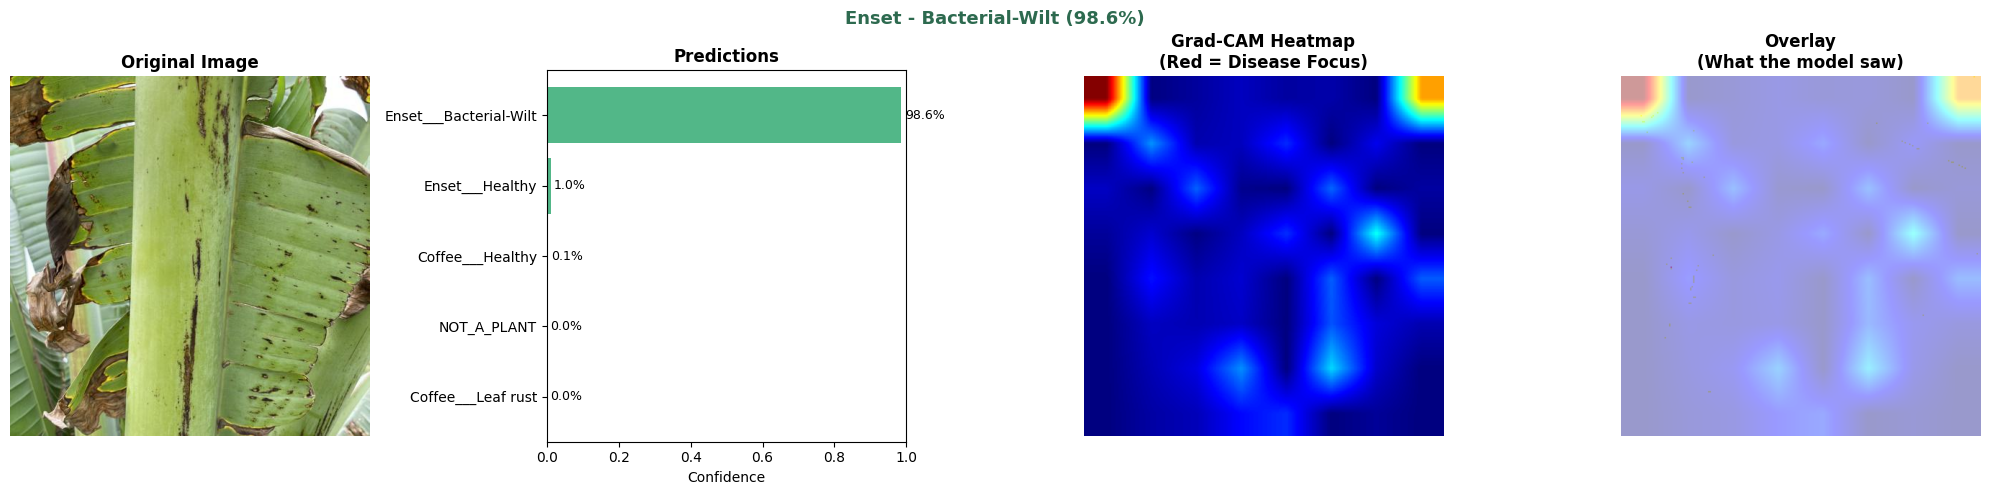


RESULT
Rejected        : False
Top prediction  : Enset___Bacterial-Wilt
Confidence      : 98.6%
Grad-CAM shown  : True

Grad-CAM saved at: /content/drive/MyDrive/plant_disease_pro/test_gradcam.png


In [ ]:
# =========================
# ONE-CELL TEST WITH UPLOAD + GRAD-CAM
# =========================

from google.colab import files
from PIL import Image as PILImage
import os

# 1. Upload image
print("Upload your image (e.g., tomato leaf)...")
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]
print(f"Using image: {image_path}")

# 2. Quick check (optional)
img = PILImage.open(image_path).convert('RGB')
img.show()

# 3. Run prediction + Grad-CAM
result = predict_with_gradcam(
    image_path,
    best_model,
    CLASS_NAMES,
    gradcam_layer=GRADCAM_LAYER,
    save_path=f'{SAVE_DIR}/test_gradcam.png'
)

# 4. Print results
print("\n" + "="*50)
print("RESULT")
print("="*50)
print(f"Rejected        : {result['rejected']}")
print(f"Top prediction  : {result['top_class']}")
print(f"Confidence      : {result['top_confidence']:.1%}")
print(f"Grad-CAM shown  : {result['gradcam_available']}")

# 5. Confirm saved output
if os.path.exists(f'{SAVE_DIR}/test_gradcam.png'):
    print(f"\nGrad-CAM saved at: {SAVE_DIR}/test_gradcam.png")

TEST 2: Car image (should be REJECTED - not a plant)


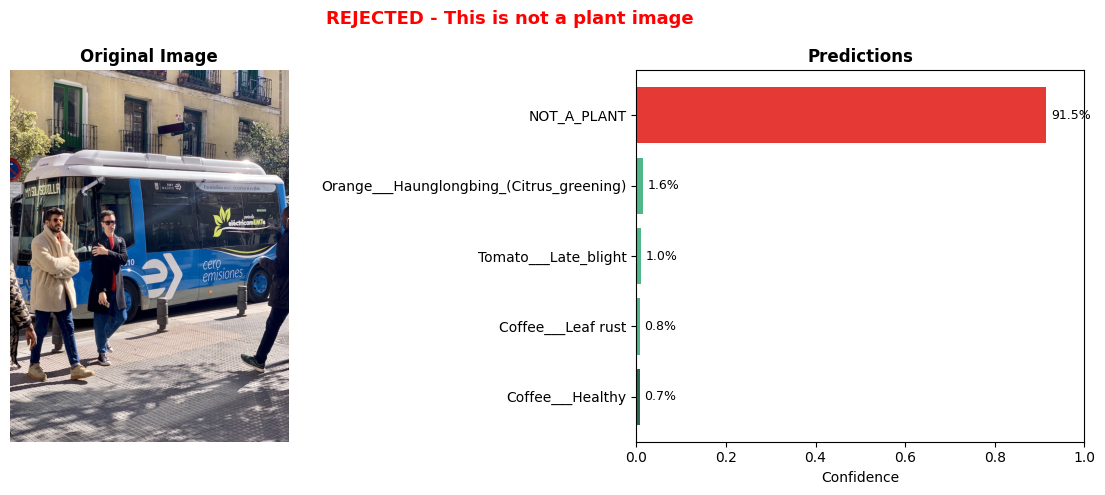

Rejected : True (should be True)


In [ ]:
print('=' * 60)
print('TEST 2: Car image (should be REJECTED - not a plant)')
print('=' * 60)

import requests
import tempfile
from PIL import Image as PILImage

# Stable image URL (works reliably in ML pipelines)
image_url = "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(image_url, headers=headers)

# Ensure valid response
if response.status_code != 200:
    raise Exception(f"Download failed: {response.status_code}")

# Save image safely
tmp = tempfile.NamedTemporaryFile(delete=False, suffix=".jpg")
tmp.write(response.content)
tmp.close()

# Load image
img = PILImage.open(tmp.name).convert("RGB")
img.show()

# Run model
result2 = predict_with_gradcam(
    tmp.name,
    best_model,
    CLASS_NAMES,
    gradcam_layer=GRADCAM_LAYER
)

print(f'Rejected : {result2["rejected"]} (should be True)')

TEST 3: Test with a local image from test dataset
True class: Grape___healthy
Saved to: /content/drive/MyDrive/plant_disease_pro/test_local_gradcam.png


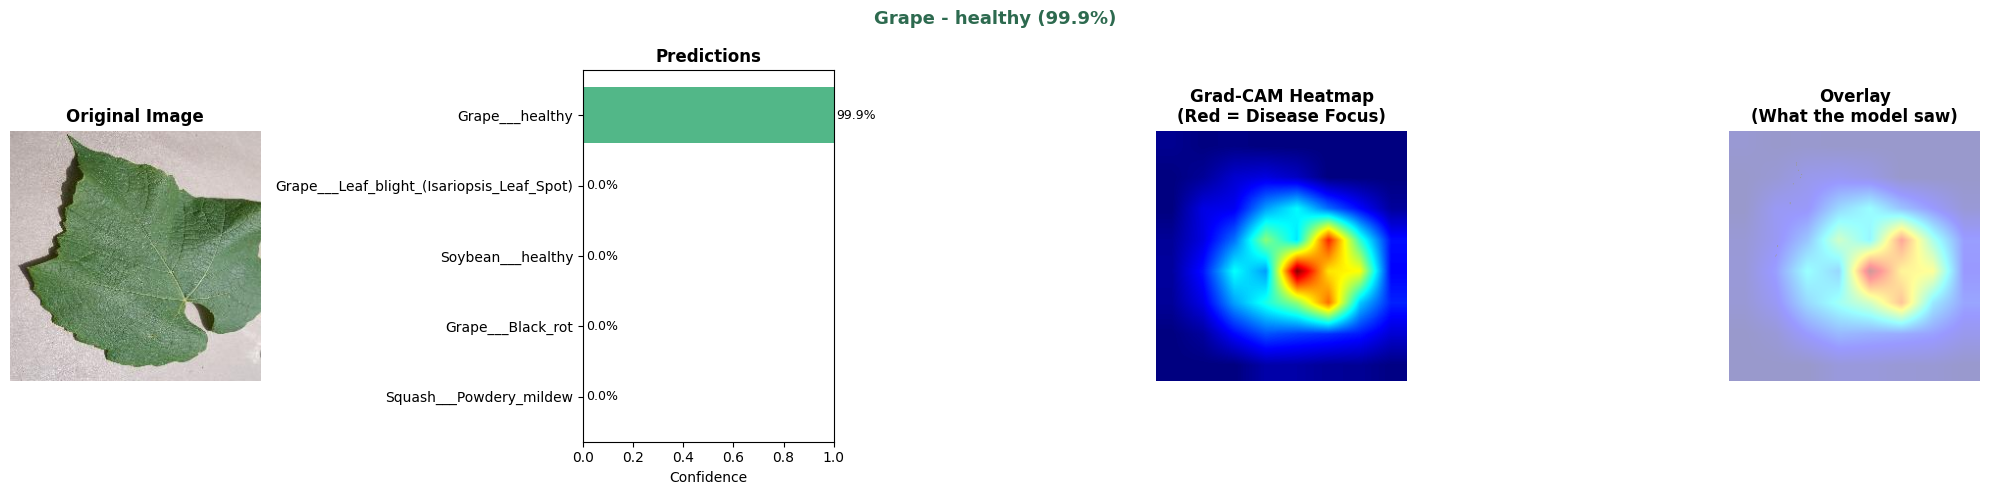

Predicted : Grape___healthy (99.9%)
Correct   : True


In [ ]:
print('=' * 60)
print('TEST 3: Test with a local image from test dataset')
print('=' * 60)

# Pick a random test image from the dataset
test_classes = os.listdir(f'{MERGED_DIR}/test')
random_class = random.choice([c for c in test_classes if c != 'NOT_A_PLANT'])
class_dir    = f'{MERGED_DIR}/test/{random_class}'
random_img   = random.choice(os.listdir(class_dir))
img_path     = f'{class_dir}/{random_img}'

print(f'True class: {random_class}')
result3 = predict_with_gradcam(
    img_path,
    best_model,
    CLASS_NAMES,
    gradcam_layer=GRADCAM_LAYER,
    save_path=f'{SAVE_DIR}/test_local_gradcam.png'
)
print(f'Predicted : {result3["top_class"]} ({result3["top_confidence"]:.1%})')
print(f'Correct   : {result3["top_class"] == random_class}')

## Cell 17 - Batch Grad-CAM Visualization (Grid)

Grid saved to: /content/drive/MyDrive/plant_disease_pro/gradcam_grid.png


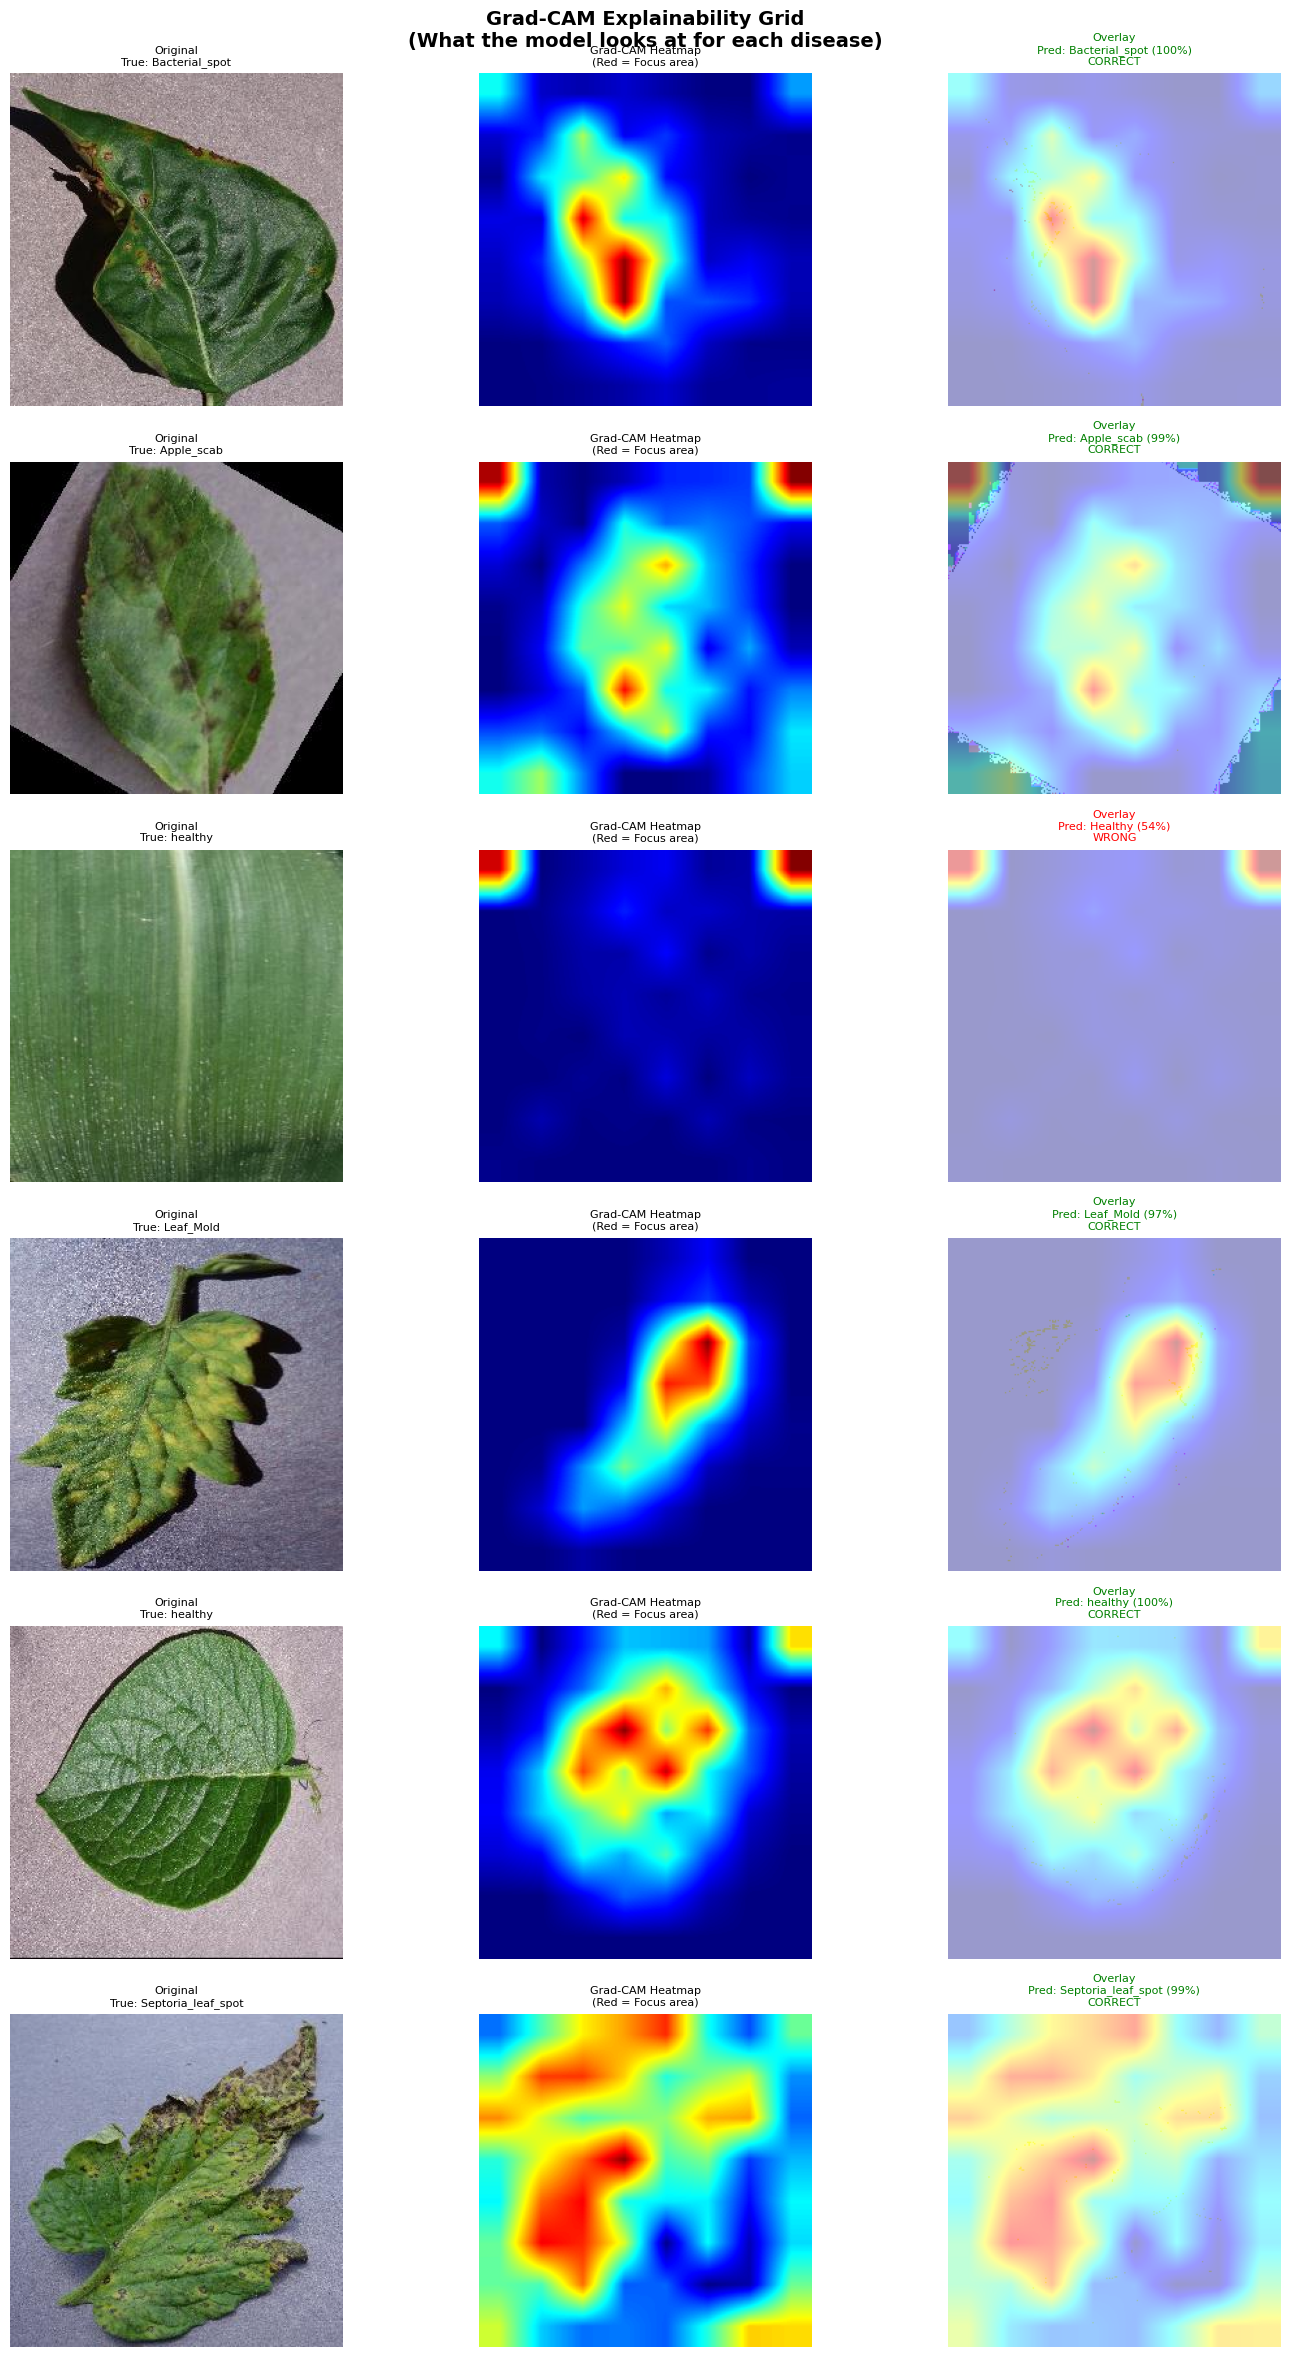

In [ ]:
def visualize_gradcam_grid(model, class_names, merged_dir,
                            gradcam_layer, n_samples=6, save_path=None):
    """
    Show Grad-CAM for multiple random test images in a grid.
    Great for your BSc report and award presentation!
    """
    test_classes = [c for c in os.listdir(f'{merged_dir}/test')
                    if c != 'NOT_A_PLANT']
    selected = random.sample(test_classes, min(n_samples, len(test_classes)))

    fig, axes = plt.subplots(n_samples, 3, figsize=(15, n_samples * 4))
    fig.suptitle('Grad-CAM Explainability Grid\n(What the model looks at for each disease)',
                 fontsize=14, fontweight='bold')

    for row, cls in enumerate(selected):
        class_dir  = f'{merged_dir}/test/{cls}'
        img_file   = random.choice(os.listdir(class_dir))
        img_path   = f'{class_dir}/{img_file}'

        orig_img   = PILImage.open(img_path).convert('RGB')
        img_r      = orig_img.resize((IMG_SIZE, IMG_SIZE))
        arr        = np.array(img_r, dtype=np.float32)
        arr        = tf.keras.applications.efficientnet.preprocess_input(arr)
        img_array  = np.expand_dims(arr, axis=0)

        probs      = model.predict(img_array, verbose=0)[0]
        pred_idx   = np.argmax(probs)
        pred_class = class_names[pred_idx]
        confidence = probs[pred_idx]

        try:
            heatmap = make_gradcam_heatmap(img_array, model, gradcam_layer, pred_idx)
            orig_arr, heatmap_arr, overlaid_arr = overlay_gradcam(img_array, heatmap)

            axes[row, 0].imshow(orig_img)
            axes[row, 0].set_title(f'Original\nTrue: {cls.split("___")[-1][:25]}',
                                    fontsize=8)

            axes[row, 1].imshow(heatmap_arr)
            axes[row, 1].set_title('Grad-CAM Heatmap\n(Red = Focus area)', fontsize=8)

            correct = pred_class == cls
            axes[row, 2].imshow(overlaid_arr)
            axes[row, 2].set_title(
                f'Overlay\nPred: {pred_class.split("___")[-1][:20]} ({confidence:.0%})\n'
                f'{"CORRECT" if correct else "WRONG"}',
                fontsize=8,
                color='green' if correct else 'red'
            )
        except Exception as e:
            for col in range(3):
                axes[row, col].text(0.5, 0.5, f'Error: {e}',
                                    ha='center', va='center')

        for col in range(3):
            axes[row, col].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Grid saved to: {save_path}')
    plt.show()


visualize_gradcam_grid(
    best_model, CLASS_NAMES, MERGED_DIR,
    GRADCAM_LAYER, n_samples=6,
    save_path=f'{SAVE_DIR}/gradcam_grid.png'
)

## Cell 18 - Save Model Info & Download

In [ ]:
model_info = {
    'model_name'          : 'PlantDiseaseProV1',
    'base_architecture'   : 'EfficientNetB4',
    'img_size'            : IMG_SIZE,
    'num_classes'         : NUM_CLASSES,
    'class_names'         : CLASS_NAMES,
    'not_a_plant_index'   : NOT_A_PLANT_IDX,
    'gradcam_layer'       : GRADCAM_LAYER,
    'rejection_threshold' : 0.60,
    'preprocessing'       : 'tf.keras.applications.efficientnet.preprocess_input',
    'test_accuracy'       : float(test_acc),
    'test_top3_accuracy'  : float(test_top3),
    'datasets_used'       : [
        'PlantVillage (vipoooool)',
        'Ethiopian Coffee (biniyamyoseph)',
        'Maize (smaranjitghose)',
        'Enset (beteaberra)'
    ]
}

with open(f'{SAVE_DIR}/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print('=' * 55)
print('ALL FILES SAVED')
print('=' * 55)
print(f'Model      : {SAVE_PATH}')
print(f'Info       : {SAVE_DIR}/model_info.json')
print(f'Classes    : {NUM_CLASSES}')
print(f'Test Acc   : {test_acc:.2%}')
print(f'Top-3 Acc  : {test_top3:.2%}')
print(f'Grad-CAM   : {GRADCAM_LAYER}')
print()
print('BACKEND model.py settings:')
print(f'  IMG_SIZE = {IMG_SIZE}')
print(f'  preprocessing = efficientnet.preprocess_input')
print(f'  GRADCAM_LAYER = "{GRADCAM_LAYER}"')
print(f'  REJECTION_THRESHOLD = 0.60')

ALL FILES SAVED
Model      : /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras
Info       : /content/drive/MyDrive/plant_disease_pro/model_info.json
Classes    : 50
Test Acc   : 86.42%
Top-3 Acc  : 99.21%
Grad-CAM   : top_activation

BACKEND model.py settings:
  IMG_SIZE = 240
  preprocessing = efficientnet.preprocess_input
  GRADCAM_LAYER = "top_activation"
  REJECTION_THRESHOLD = 0.60


In [ ]:
# Download model to your PC if not using Drive
if 'drive' not in SAVE_DIR:
    from google.colab import files
    print('Downloading model to your PC...')
    files.download(SAVE_PATH)
    files.download(f'{SAVE_DIR}/model_info.json')
    print('Download complete')
else:
    print('Model already saved to Google Drive')
    print(f'Location: {SAVE_PATH}')

Model already saved to Google Drive
Location: /content/drive/MyDrive/plant_disease_pro/plant_disease_pro.keras
